## Linear Classification EDA

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 1234

In [9]:
data = pd.read_csv("Invistico_Airline.csv")

print(data.info())
print("-"*50)
print(data.describe(include="all"))



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

### Ordinal data show order or grade

In [13]:
# split columns

y_col = ['satisfaction']
numeric_cols = ['Age', 'Flight Distance',
                   'Departure Delay in Minutes', 'Arrival Delay in Minutes']
ordinal_columns = ['Seat comfort', 'Departure/Arrival time convenient',
                   'Food and drink', 'Gate location',
                   'Inflight wifi service', 'Inflight entertainment',
                   'Online support', 'Ease of Online booking',
                   'On-board service', 'Leg room service',
                   'Baggage handling', 'Checkin service',
                   'Cleanliness', 'Online boarding']
category_columns = ['Gender', 'Customer Type',
                    'Type of Travel', 'Class']

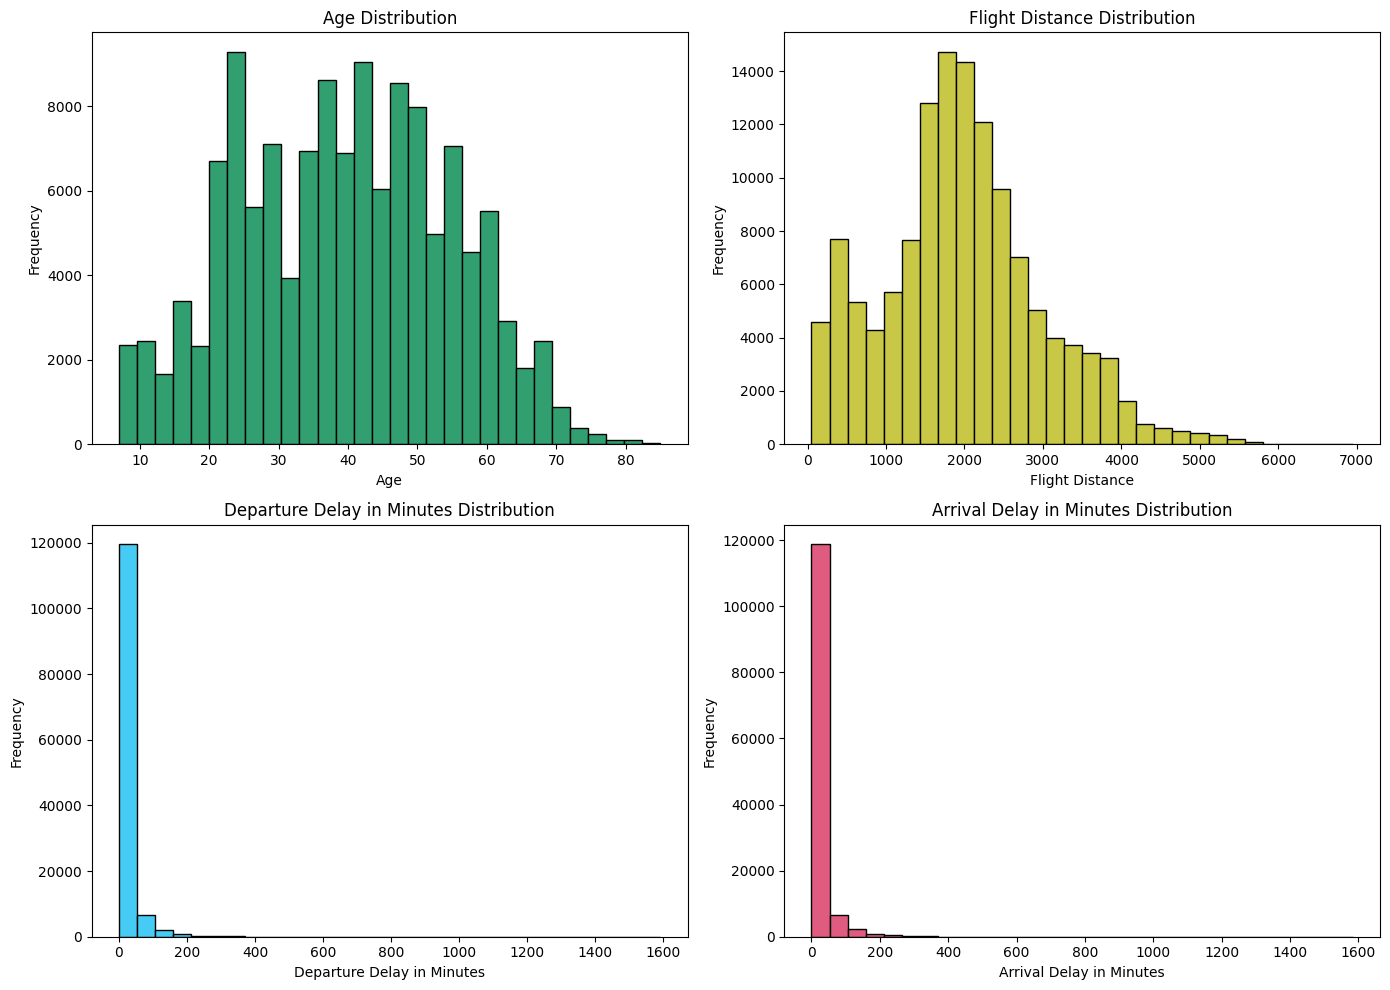

In [19]:
# numeric data plot

numeric_data = data[numeric_cols]

plt.figure(figsize=(14 ,10))

np.random.seed(seed)

for idx, numeric in enumerate(numeric_cols):
  col = (np.random.random(), np.random.random(),np.random.random())

  plt.subplot(2, 2, idx+1)
  plt.hist(numeric_data[numeric], bins=30, color=col, edgecolor="black")
  plt.title(f'{numeric} Distribution')
  plt.xlabel(numeric)
  plt.ylabel("Frequency")

plt.tight_layout()


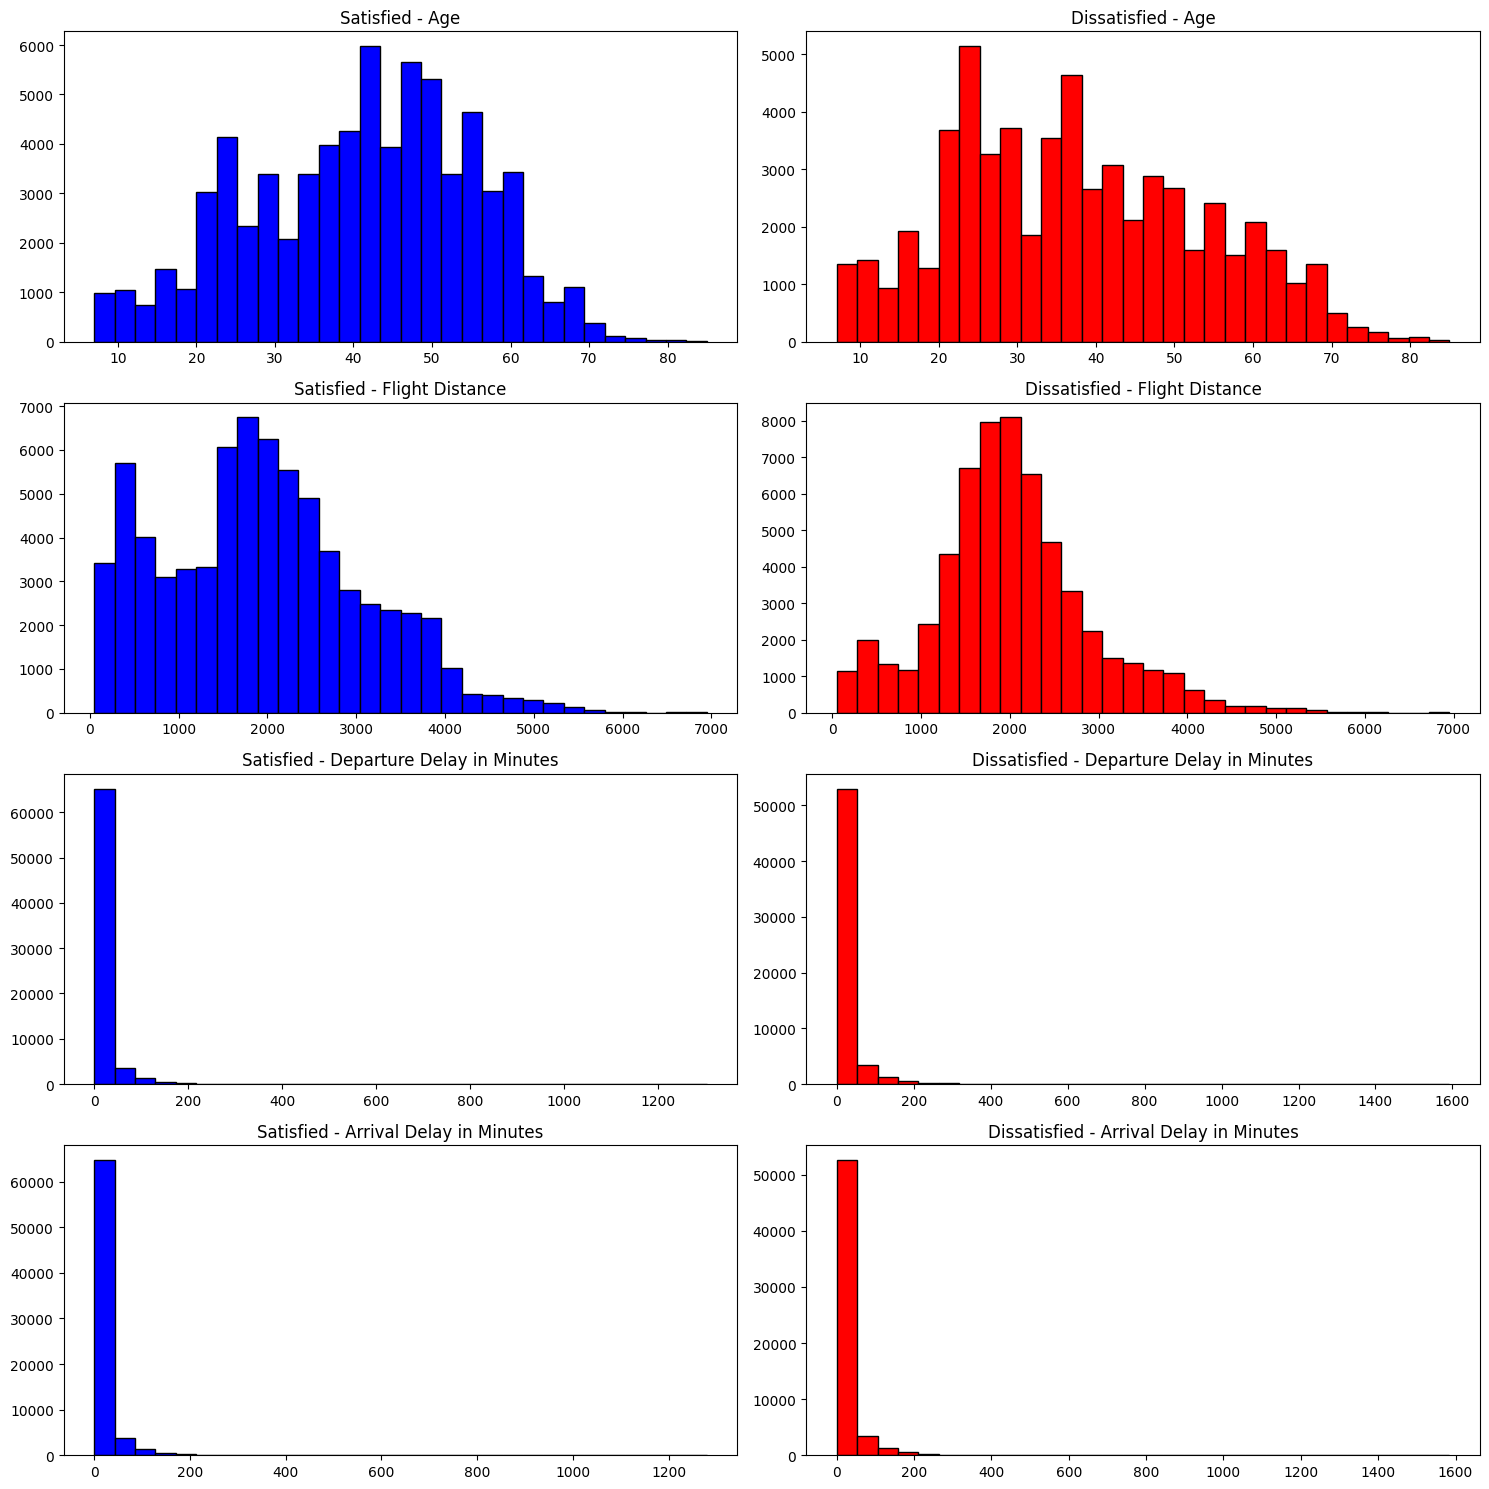

In [23]:
# plot by classes

satisfied = data[data['satisfaction'] == "satisfied"]
dissatisfied = data[data["satisfaction"] == "dissatisfied"]

plt.figure(figsize=(15, 15))

for idx, column in enumerate(numeric_cols):
  plt.subplot(len(numeric_cols), 2, 2*idx+1)
  plt.hist(satisfied[column], color="blue", label="Satisfied", bins=30, edgecolor="black")
  plt.title(f'Satisfied - {column}')

  plt.subplot(len(numeric_cols), 2, 2*idx+2)
  plt.hist(dissatisfied[column], color="red", label="Dissatisfied", bins=30, edgecolor="black")
  plt.title(f'Dissatisfied - {column}')

plt.tight_layout()


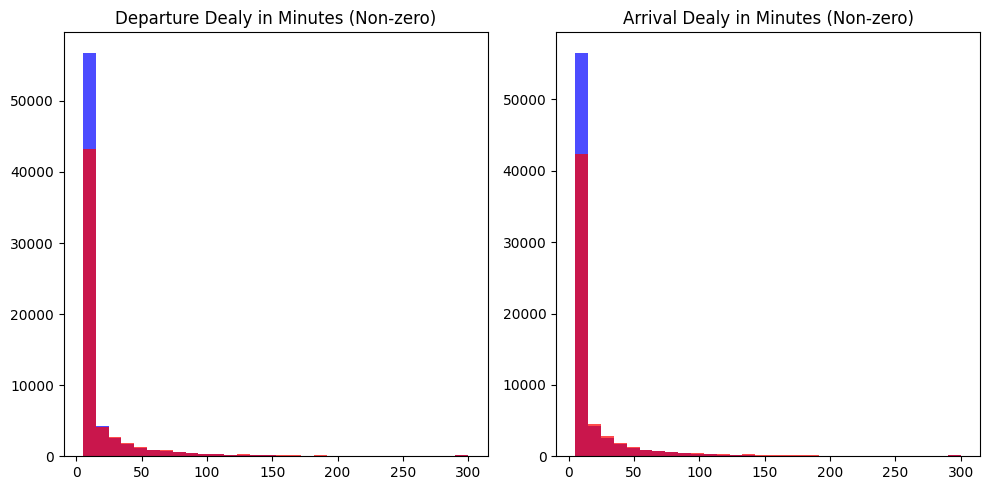

In [25]:
 # By special time

def clip_delays(df, min_value, max_value):
  # clit fuc : chages under/upper values to min/max values
  df['Departure Delay in Minutes'] = df['Departure Delay in Minutes'].clip(min_value, max_value)
  df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].clip(min_value, max_value)
  return df

min_delay = 5
max_delay = 300

satisfied_clipped = clip_delays(satisfied.copy(), min_delay, max_delay)
dissatisfied_clipped = clip_delays(dissatisfied.copy(), min_delay, max_delay)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(satisfied_clipped['Departure Delay in Minutes'], color='blue', label="Satisfied",
         bins=30, alpha=0.7)
plt.hist(dissatisfied_clipped['Departure Delay in Minutes'], color='red', label="Dissatisfied",
         bins=30, alpha=0.7)
plt.title('Departure Dealy in Minutes (Non-zero)')

plt.subplot(1, 2, 2)
plt.hist(satisfied_clipped['Arrival Delay in Minutes'].dropna(), color='blue', label="Satisfied",
         bins=30, alpha=0.7)
plt.hist(dissatisfied_clipped['Arrival Delay in Minutes'].dropna(), color='red', label="Dissatisfied",
         bins=30, alpha=0.7)
plt.title('Arrival Dealy in Minutes (Non-zero)')

plt.tight_layout()


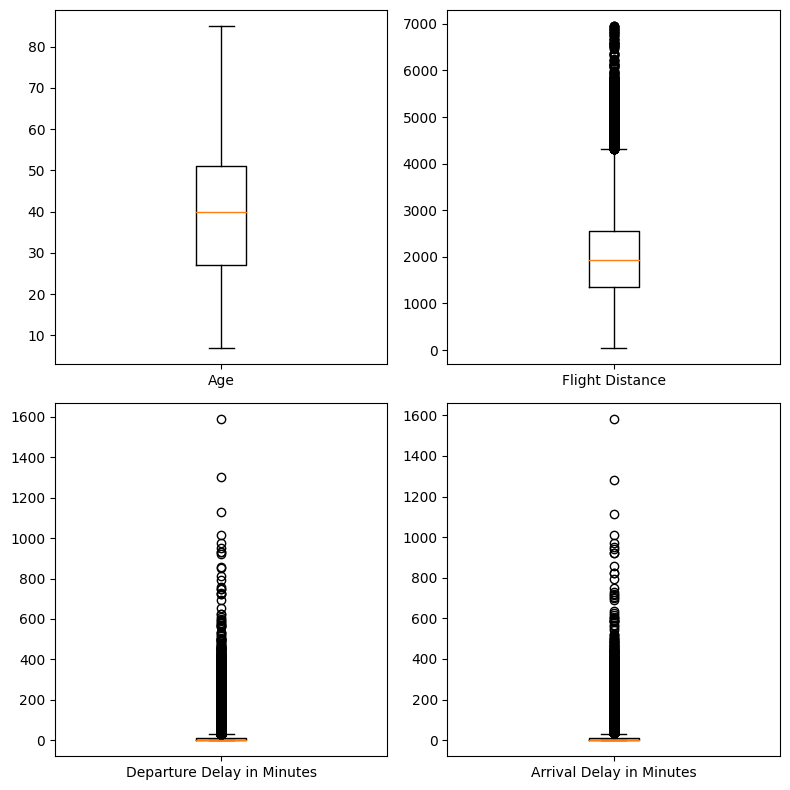

In [29]:
# outline ckeck

plt.figure(figsize=(8, 8))

np.random.seed(seed)
for idx, numeric in enumerate(numeric_cols):
  plt.subplot(2, 2, idx+1)
  plt.boxplot(numeric_data[numeric].dropna(), labels=[numeric])

plt.tight_layout()

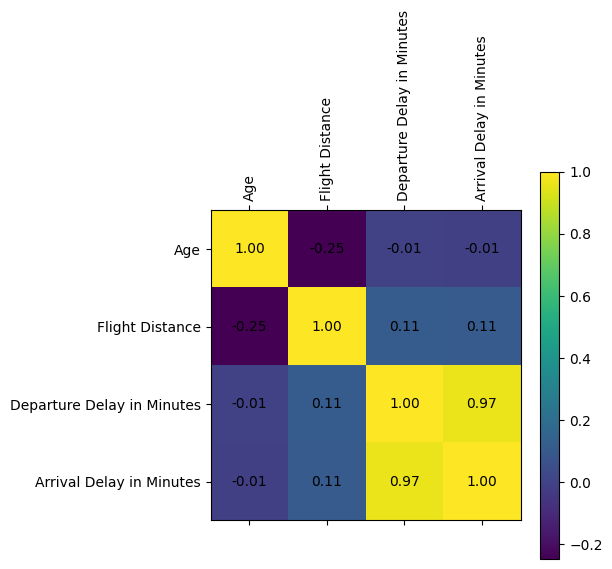

                                 Age  Flight Distance  \
Age                         1.000000        -0.249625   
Flight Distance            -0.249625         1.000000   
Departure Delay in Minutes -0.009041         0.112555   
Arrival Delay in Minutes   -0.011248         0.110103   

                            Departure Delay in Minutes  \
Age                                          -0.009041   
Flight Distance                               0.112555   
Departure Delay in Minutes                    1.000000   
Arrival Delay in Minutes                      0.965291   

                            Arrival Delay in Minutes  
Age                                        -0.011248  
Flight Distance                             0.110103  
Departure Delay in Minutes                  0.965291  
Arrival Delay in Minutes                    1.000000  


In [32]:
# corr

corr_matrix = numeric_data.corr()

plt.figure(figsize=(5, 5))

plt.matshow(corr_matrix, fignum=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

for (i, j), val in np.ndenumerate(corr_matrix):
  plt.text(j, i, '{:0.2f}'.format(val), ha='center', va="center", color='black')

plt.show()

print(corr_matrix)

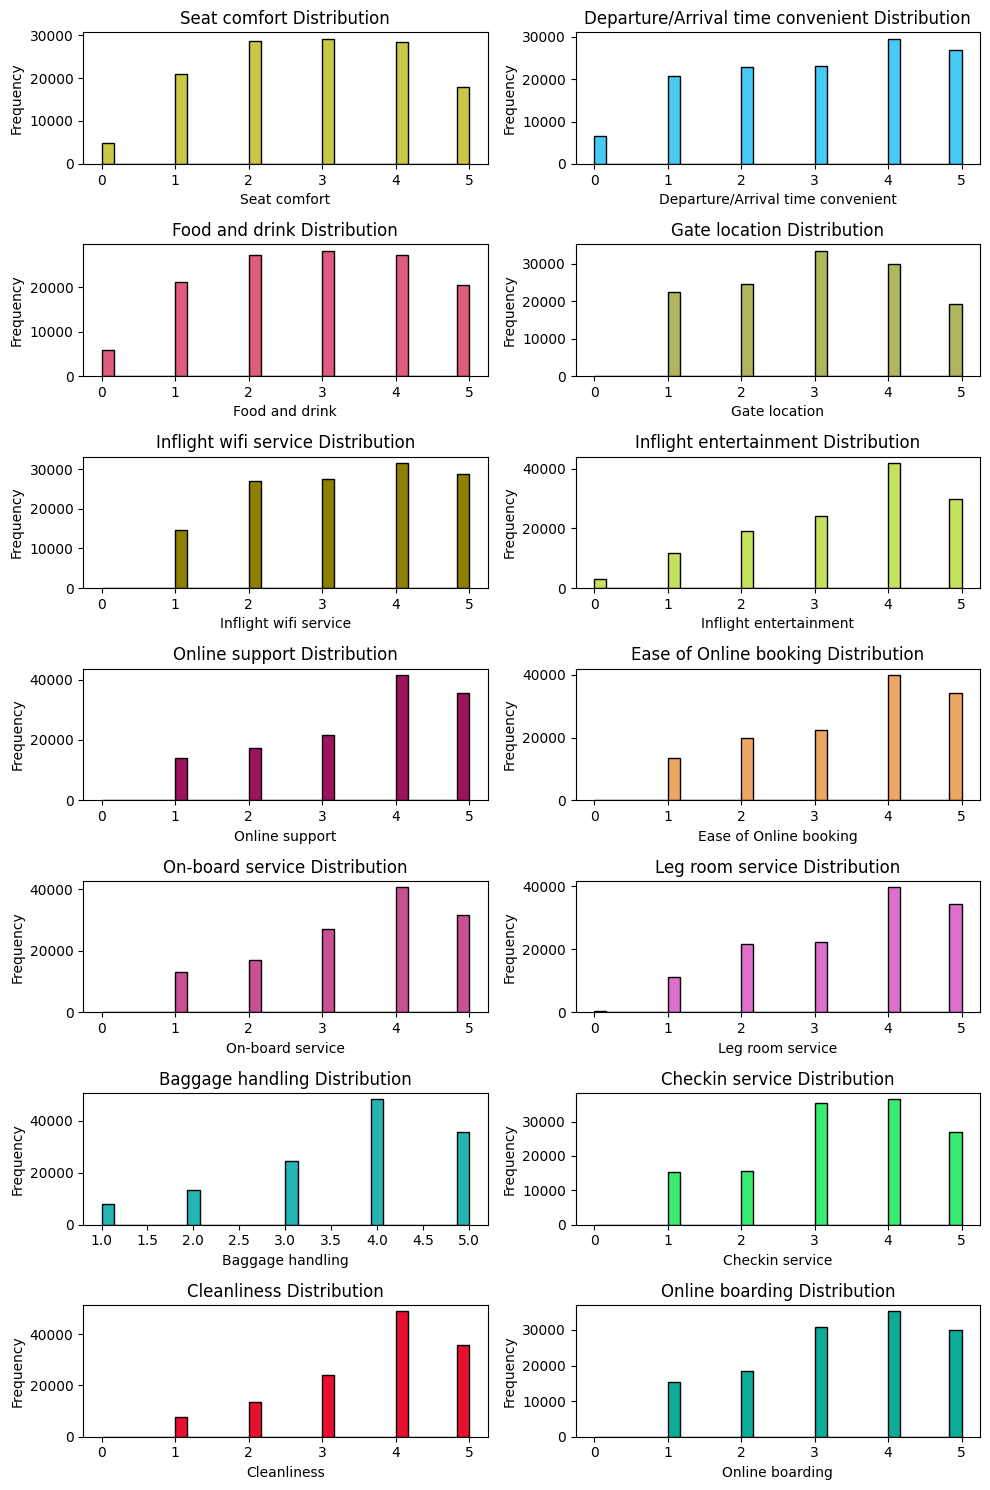

In [34]:
# ordinal data plot

ordinal_data = data[ordinal_columns]

plt.figure(figsize=(10, 15))

for idx, ordinal in enumerate(ordinal_data):
  col = (np.random.random(), np.random.random(), np.random.random())

  plt.subplot(7, 2, idx+1)
  plt.hist(ordinal_data[ordinal], bins=30, color=col, edgecolor='black')
  plt.title(f'{ordinal} Distribution')
  plt.xlabel(ordinal)
  plt.ylabel('Frequency')

plt.tight_layout()

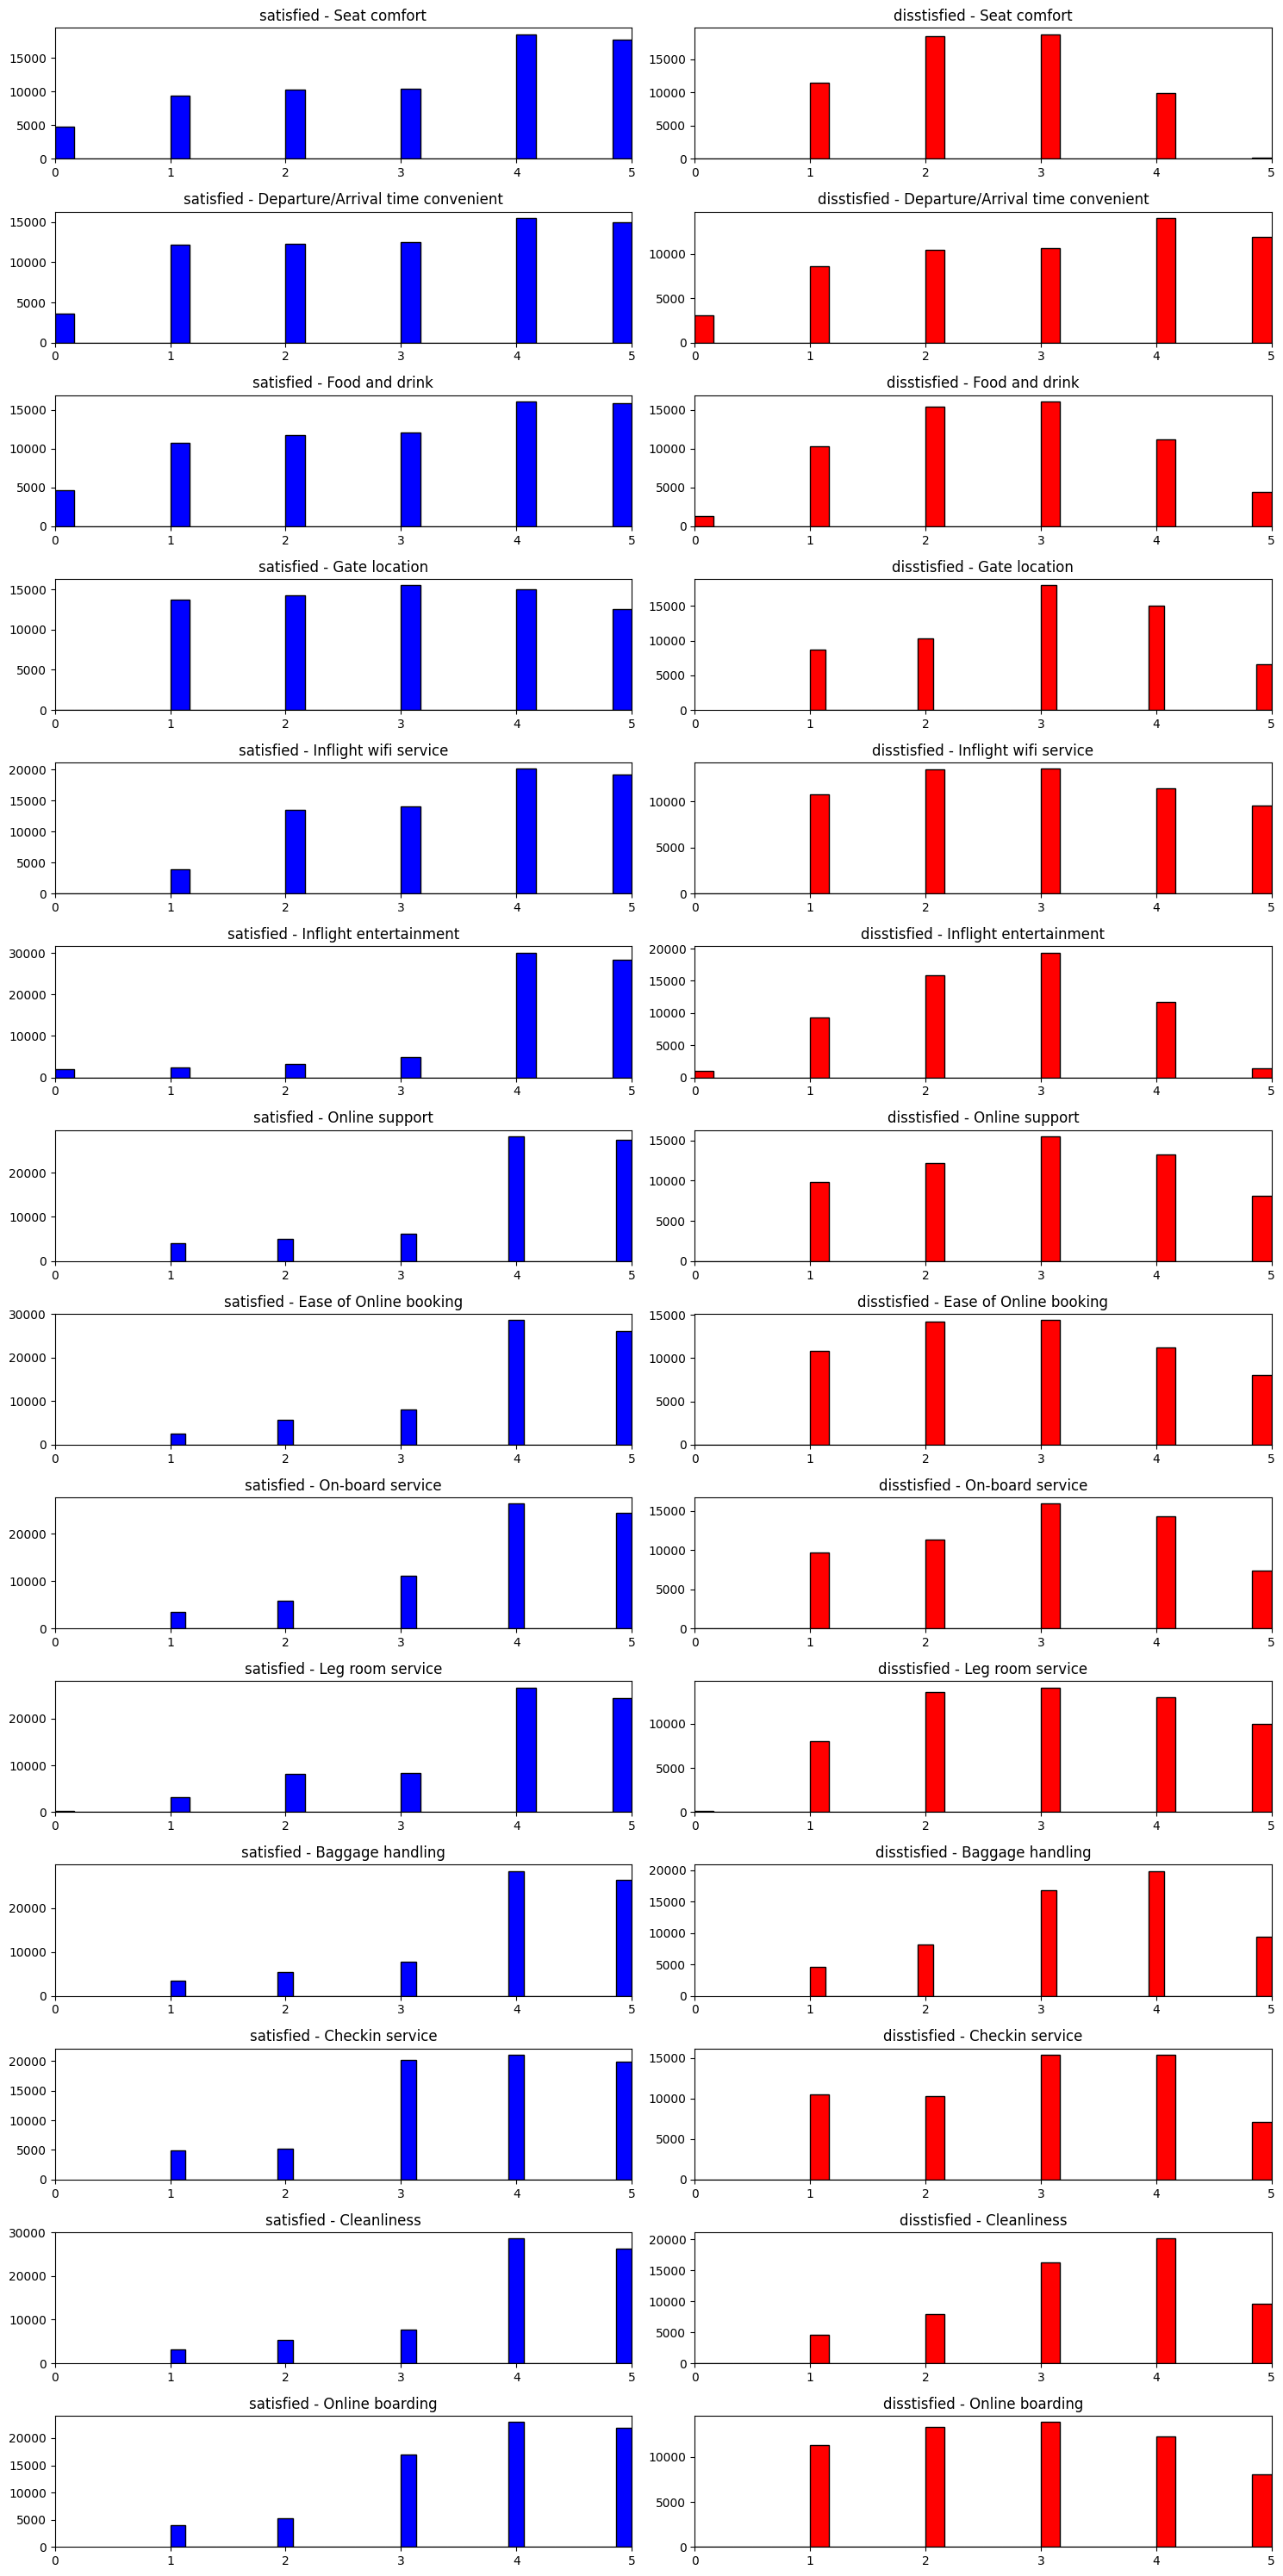

In [36]:
plt.figure(figsize=(15, 30))

for idx, column in enumerate(ordinal_columns):
  plt.subplot(len(ordinal_columns), 2, 2*idx+1)
  plt.hist(satisfied[column], color="blue", label="satisfied",
           bins=30, edgecolor='black')
  plt.xlim(0, 5)
  plt.title(f'satisfied - {column}')

  plt.subplot(len(ordinal_columns), 2, 2*idx+2)
  plt.hist(dissatisfied[column], color='red', label='disstisfied',
           bins=30, edgecolor='black')
  plt.xlim(0, 5)
  plt.title(f'disstisfied - {column}')

plt.tight_layout()


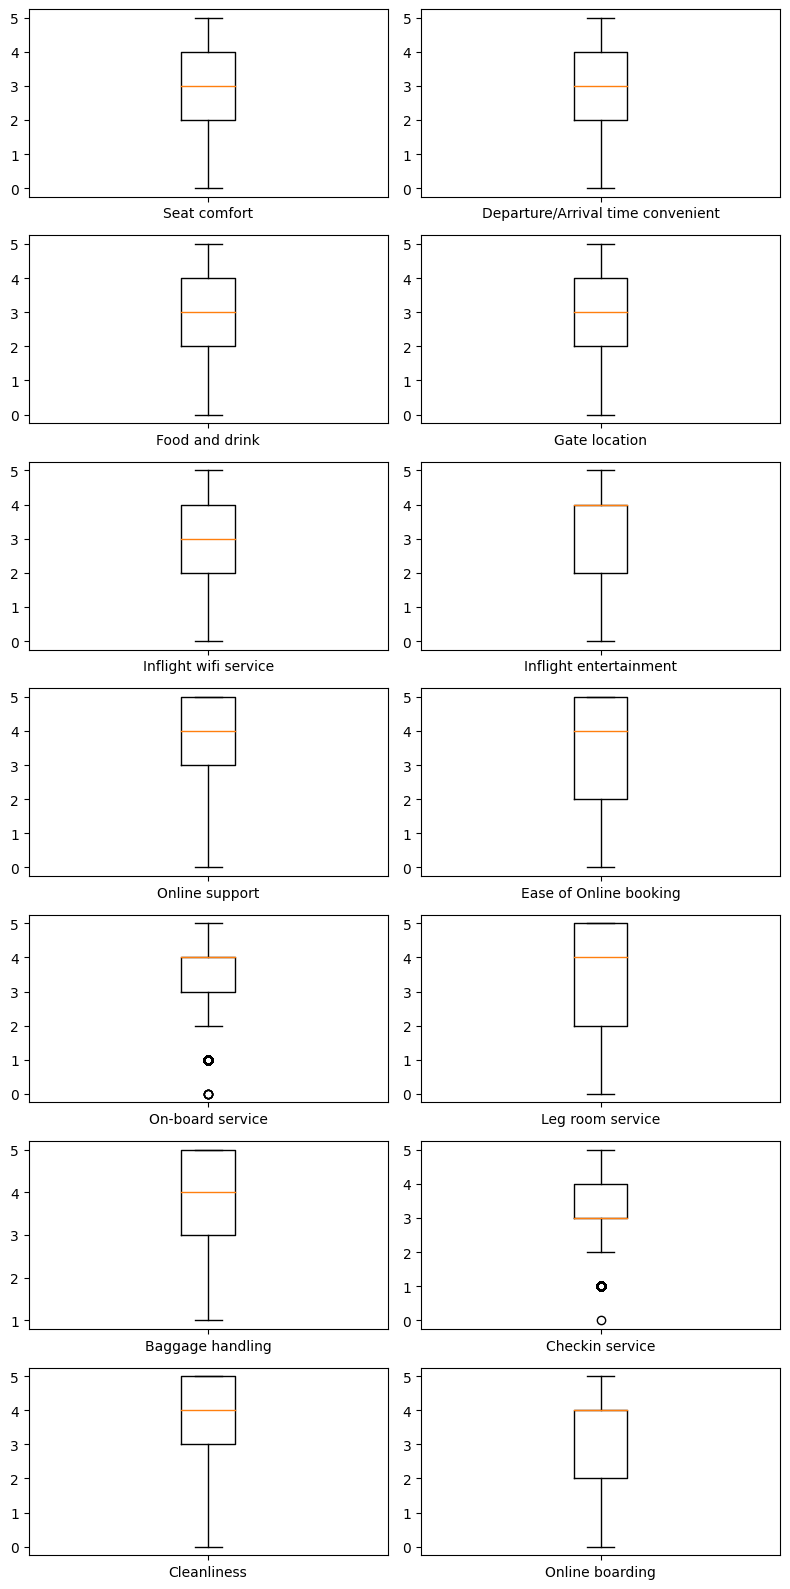

In [38]:
plt.figure(figsize=(8, 16))

for idx, ordinal in enumerate(ordinal_columns):
  plt.subplot(len(ordinal_columns)//2, 2, idx+1)
  plt.boxplot(ordinal_data[ordinal].dropna(), labels=[ordinal])

plt.tight_layout()

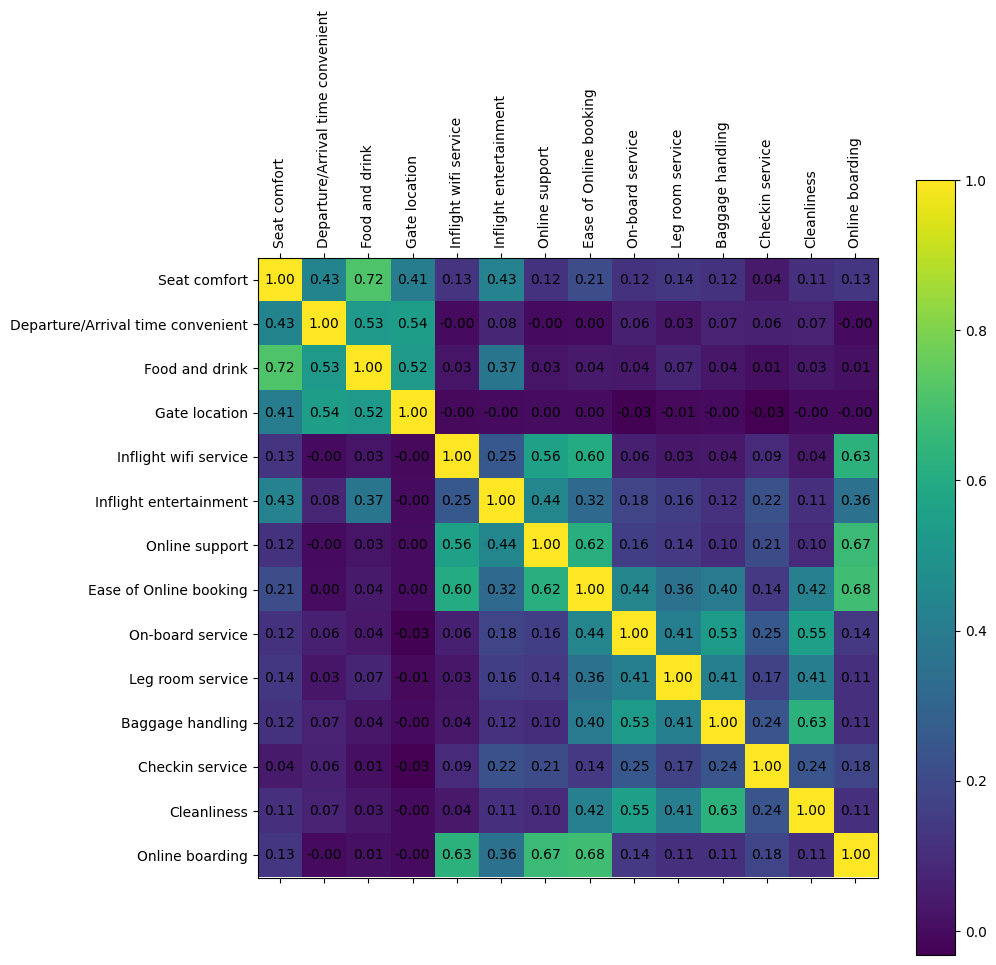

In [39]:
corr_matrix = ordinal_data.corr()

plt.figure(figsize=(10, 10))

plt.matshow(corr_matrix, fignum=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.columns)

for (i, j), val in np.ndenumerate(corr_matrix):
  plt.text(j, i, '{:0.2f}'.format(val), ha='center', va='center', color='black')

plt.show()

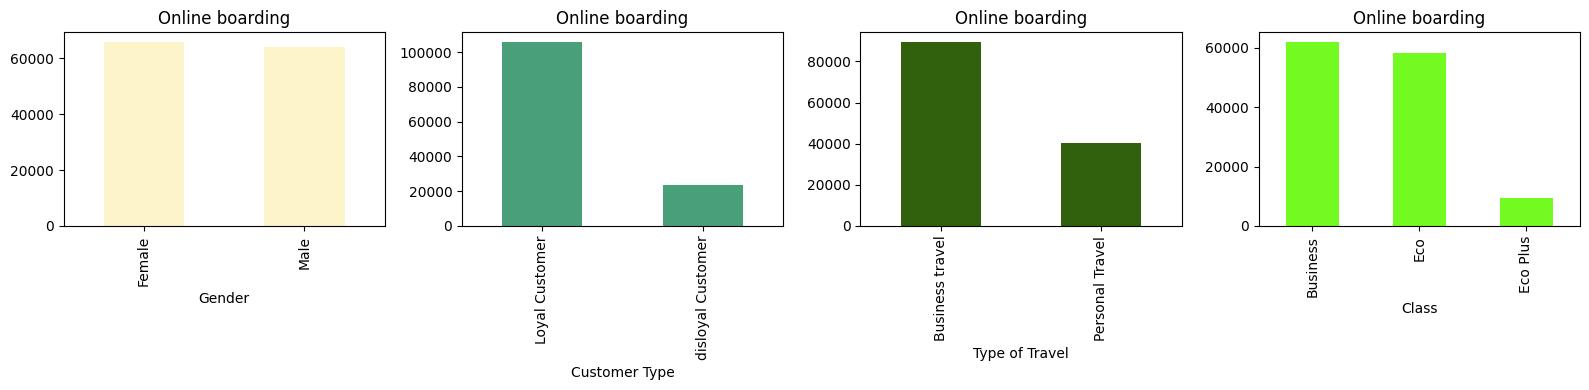

In [41]:
# category data plot

category_data = data[category_columns]

plt.figure(figsize=(16, 4))

for idx, category in enumerate(category_data):
  col = (np.random.random(), np.random.random(), np.random.random())

  plt.subplot(1, 4, idx+1)
  category_data[category].value_counts().plot(kind='bar', color=col)
  plt.title(column)
  plt.tight_layout()

plt.tight_layout()



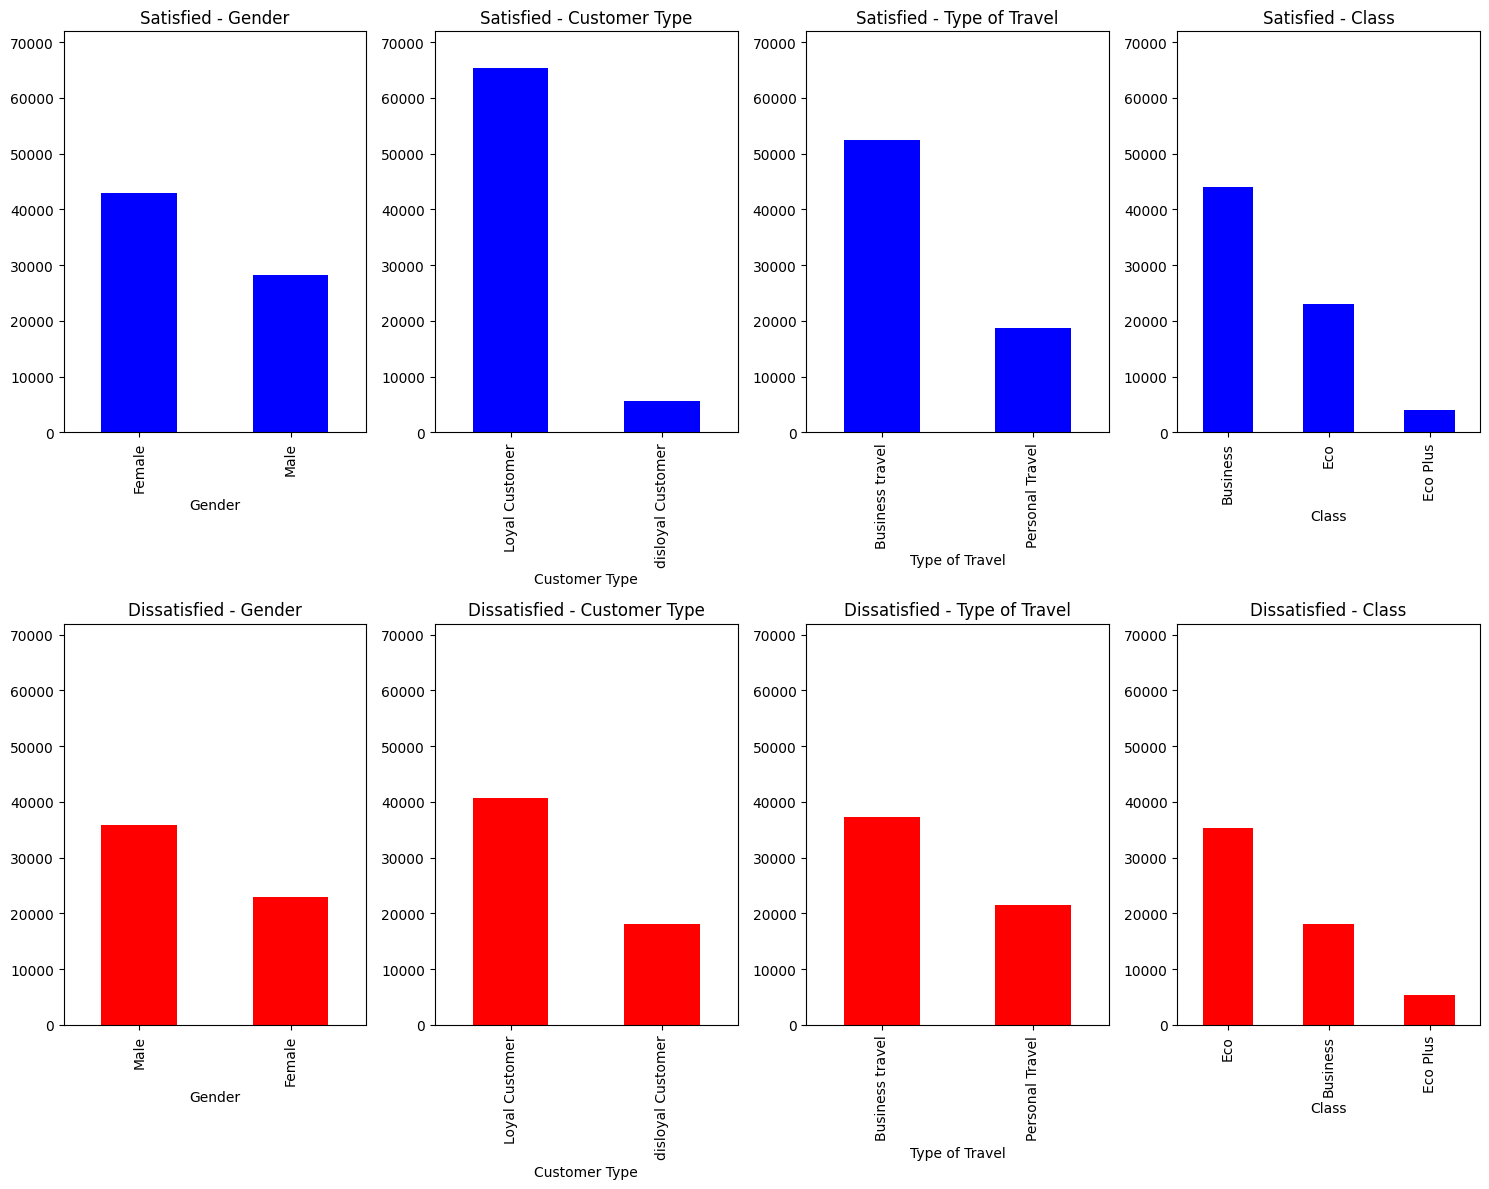

In [45]:
plt.figure(figsize=(15, 12))

max_counts_satisfied = max(satisfied[column].value_counts().max() for column in category_columns)
max_counts_dissatisfied = max(dissatisfied[column].value_counts().max() for column in  category_columns)
max_counts = max(max_counts_satisfied, max_counts_dissatisfied) * 1.1

for idx, col in enumerate(category_columns):
  plt.subplot(2, 4, idx+1)
  satisfied[col].value_counts().plot(kind='bar', color='blue')
  plt.title(f'Satisfied - {col}')
  plt.ylim(0, max_counts)
  plt.tight_layout()

  plt.subplot(2, 4, idx+5)
  dissatisfied[col].value_counts().plot(kind='bar', color='red')
  plt.title(f'Dissatisfied - {col}')
  plt.ylim(0, max_counts)
  plt.tight_layout()




In [48]:
# preprosessin

data_cleand = data.dropna()
time_limit = 300 # remove upper 5 times
data_cleand = data_cleand[
    (data_cleand['Arrival Delay in Minutes'] < time_limit) &
    (data_cleand['Departure Delay in Minutes'] < time_limit)
]

data_cleand

,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0
5,satisfied,Male,Loyal Customer,30,Personal Travel,Eco,1894,0,0,0,...,2,2,5,4,5,5,4,2,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,satisfied,Female,disloyal Customer,29,Personal Travel,Eco,1731,5,5,5,...,2,2,3,3,4,4,4,2,0,0.0
129876,dissatisfied,Male,disloyal Customer,63,Personal Travel,Business,2087,2,3,2,...,1,3,2,3,3,1,2,1,174,172.0
129877,dissatisfied,Male,disloyal Customer,69,Personal Travel,Eco,2320,3,0,3,...,2,4,4,3,4,2,3,2,155,163.0
129878,dissatisfied,Male,disloyal Customer,66,Personal Travel,Eco,2450,3,2,3,...,2,3,3,2,3,2,1,2,193,205.0


In [50]:
# encoding

data_cate_encoded = pd.get_dummies(data_cleand[category_columns], drop_first=True)
data_target_encoded = pd.get_dummies(data_cleand[y_col], drop_first=True)

data_conbined = pd.concat(
    [data_target_encoded, data_cleand[numeric_cols + ordinal_columns],
     data_cate_encoded], axis=1
)

data_conbined

,satisfaction_satisfied,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,...,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,True,65,265,0,0.0,0,0,0,2,2,...,0,3,5,3,2,False,False,True,True,False
2,True,15,2138,0,0.0,0,0,0,3,2,...,3,4,4,4,2,False,False,True,True,False
3,True,60,623,0,0.0,0,0,0,3,3,...,0,1,4,1,3,False,False,True,True,False
4,True,70,354,0,0.0,0,0,0,3,4,...,0,2,4,2,5,False,False,True,True,False
5,True,30,1894,0,0.0,0,0,0,3,2,...,4,5,5,4,2,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,True,29,1731,0,0.0,5,5,5,3,2,...,3,4,4,4,2,False,True,True,True,False
129876,False,63,2087,174,172.0,2,3,2,4,2,...,3,3,1,2,1,True,True,True,False,False
129877,False,69,2320,155,163.0,3,0,3,3,3,...,3,4,2,3,2,True,True,True,True,False
129878,False,66,2450,193,205.0,3,2,3,2,3,...,2,3,2,1,2,True,True,True,True,False


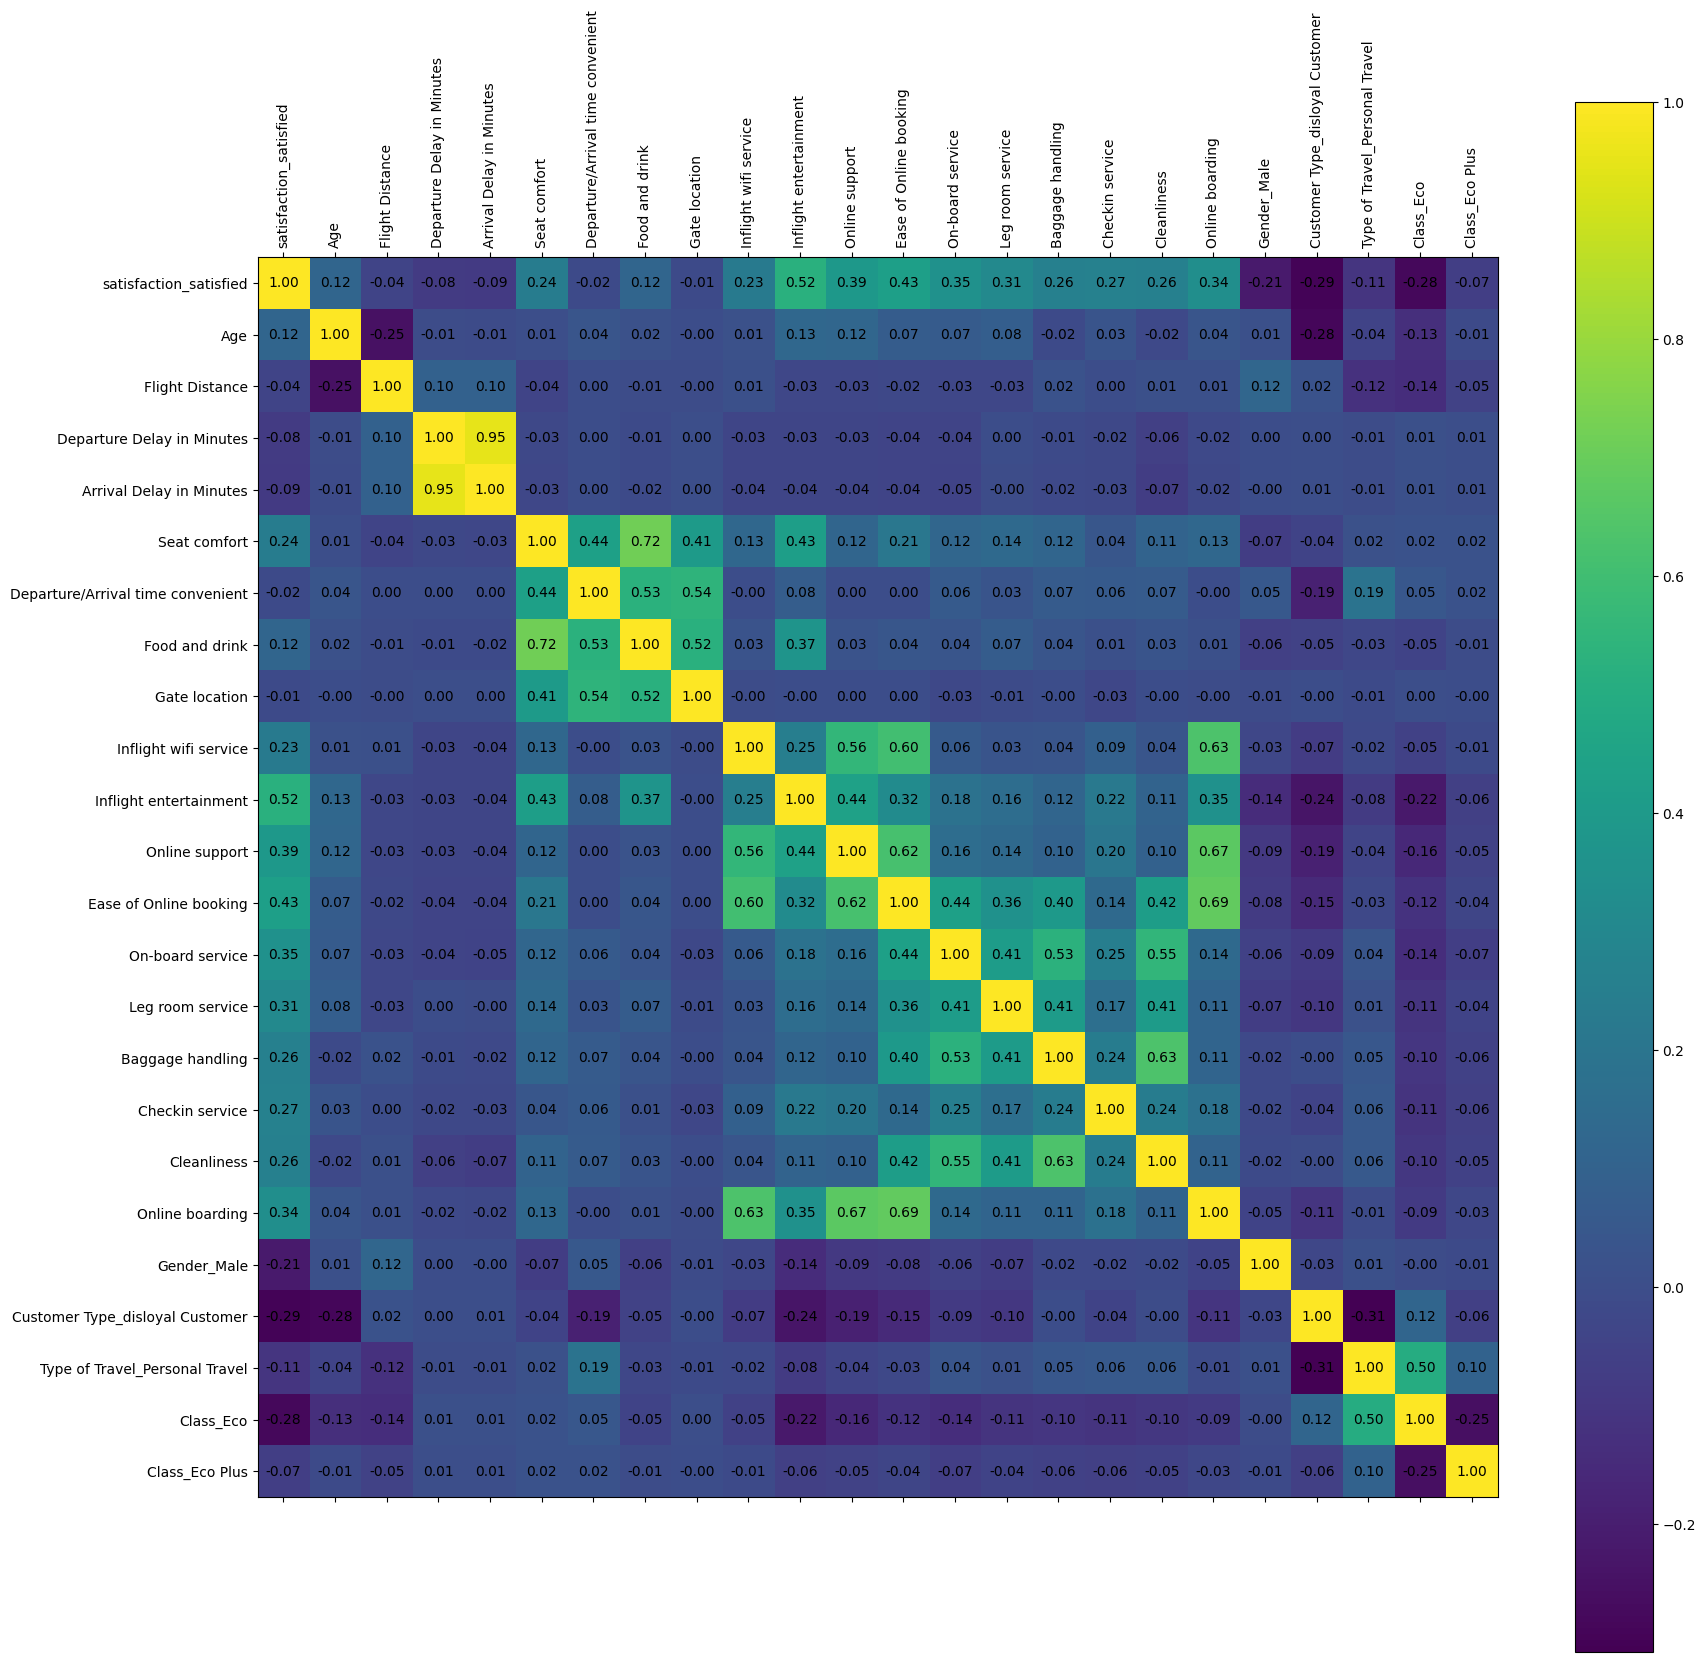

In [55]:
# total corr

corr_mat = data_conbined.corr()

plt.figure(figsize=(20, 20))

plt.matshow(corr_mat, fignum=1)
plt.colorbar()
plt.xticks(range(len(corr_mat)), corr_mat.columns, rotation=90)
plt.yticks(range(len(corr_mat)), corr_mat.columns)


for (i, j), val in np.ndenumerate(corr_mat):
  plt.text(j, i, '{:0.2f}'.format(val), ha="center", va="center", color="black")


In [59]:
# select features

select_num = 15
target_corr = corr_mat[data_target_encoded.columns[0]].abs().sort_values(ascending=False)
top_features_with_target = target_corr[1:select_num+1].index.tolist()
top_features_with_target



['Inflight entertainment',
 'Ease of Online booking',
 'Online support',
 'On-board service',
 'Online boarding',
 'Leg room service',
 'Customer Type_disloyal Customer',
 'Class_Eco',
 'Checkin service',
 'Baggage handling',
 'Cleanliness',
 'Seat comfort',
 'Inflight wifi service',
 'Gender_Male',
 'Food and drink']

In [61]:
data_set = data_conbined[target_corr[:select_num+1].index.tolist()]
data_set

,satisfaction_satisfied,Inflight entertainment,Ease of Online booking,Online support,On-board service,Online boarding,Leg room service,Customer Type_disloyal Customer,Class_Eco,Checkin service,Baggage handling,Cleanliness,Seat comfort,Inflight wifi service,Gender_Male,Food and drink
0,True,4,3,2,3,2,0,False,True,5,3,3,0,2,False,0
2,True,0,2,2,3,2,3,False,True,4,4,4,0,2,False,0
3,True,4,1,3,1,3,0,False,True,4,1,1,0,3,False,0
4,True,3,2,4,2,5,0,False,True,4,2,2,0,4,False,0
5,True,0,2,2,5,2,4,False,True,5,5,4,0,2,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,True,5,2,2,3,2,3,True,True,4,4,4,5,2,False,5
129876,False,1,3,1,2,1,3,True,False,1,3,2,2,2,True,2
129877,False,2,4,2,4,2,3,True,True,2,4,3,3,3,True,3
129878,False,2,3,2,3,2,2,True,True,2,3,1,3,3,True,3


In [62]:
y_column = ['satisfaction_satisfied']
ordinal_columns = ['Inflight entertainment', 'Ease of Online booking',
                   'Online support', 'On-board service',
                   'Online boarding', 'Leg room service',
                   'Checkin service', 'Baggage handling',
                   'Cleanliness', 'Seat comfort',
                   'Inflight wifi service', 'Food and drink']
category_columns = ['Customer Type_disloyal Customer', 'Class_Eco',
                    'Gender_Male']



In [66]:
# modeling
from sklearn.model_selection import train_test_split

X = data_set.drop(y_column, axis=1)
y = data_set[y_column]

X_ta, X_te, y_ta, y_te = train_test_split(
    X, y, test_size=0.2)

from sklearn.linear_model import LogisticRegression
lg = LogisticRegression()
lg.fit(X_ta, y_ta)

coefficients = lg.coef_
intercept = lg.intercept_

print("#"*20)
print("Parameters : ", coefficients)
print("#"*20)
print("Intercept : ", intercept)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


####################
Parameters :  [[ 0.72600912  0.30986041  0.09269853  0.28949523  0.10968811  0.21467149
  -1.32476913 -0.93717953  0.24617965  0.05999392  0.04162137  0.26165404
  -0.08452908 -0.99130461 -0.26865178]]
####################
Intercept :  [-5.41215117]


In [67]:
# acc score
from sklearn.metrics import accuracy_score

y_trian_pred = lg.predict(X_ta)
y_test_pred = lg.predict(X_te)

acc_train = accuracy_score(y_ta, y_trian_pred)
acc_test = accuracy_score(y_te, y_test_pred)

print("Train ACC : ", acc_train)
print("Test ACC :", acc_test)

Train ACC :  0.8281826188793929
Test ACC : 0.8279132791327913


In [69]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_train = confusion_matrix(y_ta, y_trian_pred)
cm_test = confusion_matrix(y_te, y_test_pred)


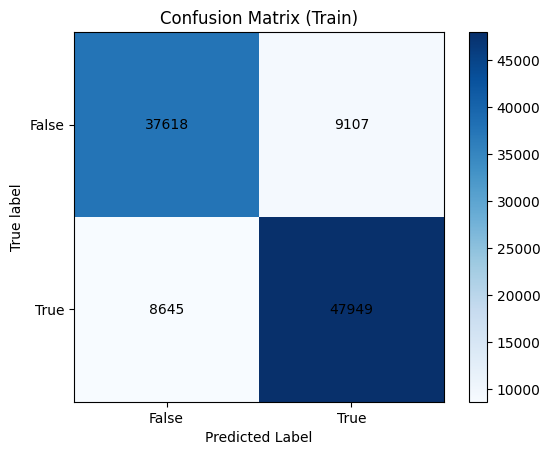

In [73]:
plt.imshow(cm_train, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (Train)')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_ta)))
plt.xticks(tick_marks, np.unique(y_ta))
plt.yticks(tick_marks, np.unique(y_ta))
plt.xlabel('Predicted Label')
plt.ylabel('True label')

for i in range(cm_train.shape[0]):
  for j in range(cm_train.shape[1]):
    plt.text(j, i, cm_train[i, j], ha='center', va='center', color='black')



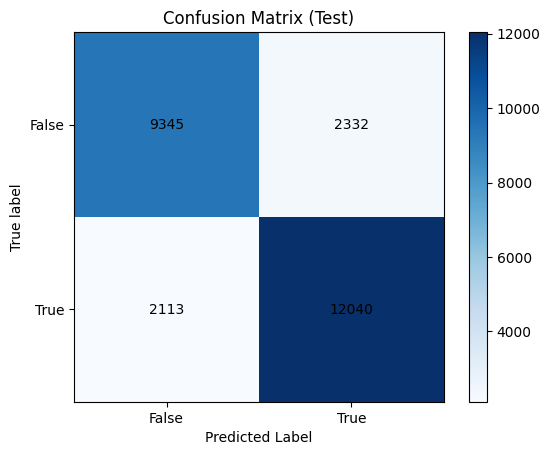

In [74]:
plt.imshow(cm_test, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (Test)')
plt.colorbar()

tick_marks = np.arange(len(np.unique(y_te)))
plt.xticks(tick_marks, np.unique(y_te))
plt.yticks(tick_marks, np.unique(y_te))
plt.xlabel('Predicted Label')
plt.ylabel('True label')

for i in range(cm_test.shape[0]):
  for j in range(cm_test.shape[1]):
    plt.text(j, i, cm_test[i, j], ha='center', va='center', color='black')



In [75]:
# Result

coeff_df = pd.DataFrame({'feature': X_ta.columns,
                         'coefficient' : lg.coef_.flatten()})
coeff_df['abs_coef'] = coeff_df['coefficient'].abs()
coeff_df_sorted = coeff_df.sort_values(by='abs_coef', ascending=False)

coeff_df

,feature,coefficient,abs_coef
0,Inflight entertainment,0.726009,0.726009
1,Ease of Online booking,0.309860,0.309860
2,Online support,0.092699,0.092699
3,On-board service,0.289495,0.289495
4,Online boarding,0.109688,0.109688
5,Leg room service,0.214671,0.214671
6,Customer Type_disloyal Customer,-1.324769,1.324769
7,Class_Eco,-0.937180,0.937180
8,Checkin service,0.246180,0.246180
9,Baggage handling,0.059994,0.059994


Text(0.5, 1.0, 'Features Importance')

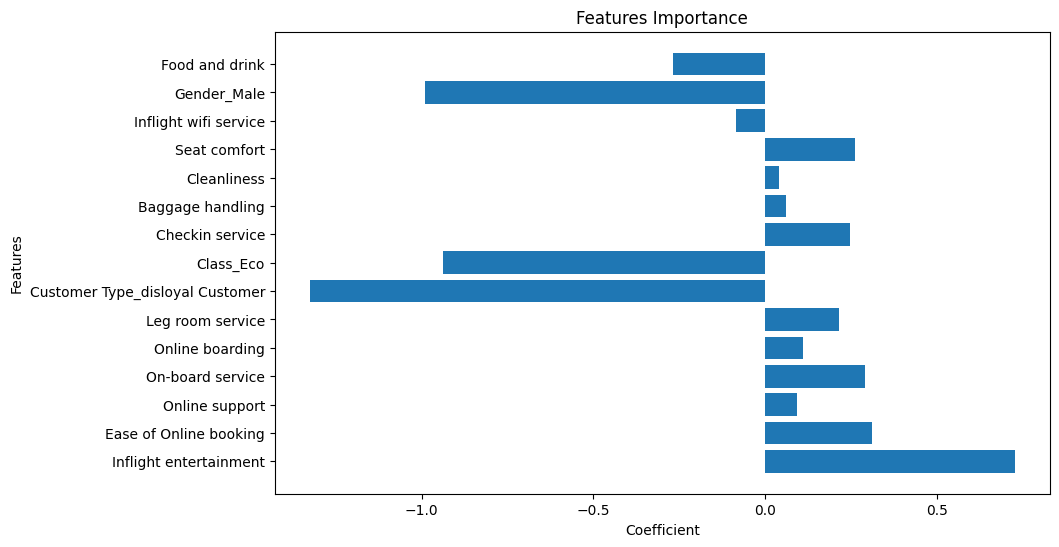

In [76]:
plt.figure(figsize=(10, 6))
plt.barh(X_ta.columns, lg.coef_.flatten())
plt.xlabel("Coefficient")
plt.ylabel('Features')
plt.title('Features Importance')
